In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## task 1

In [5]:
def rosenbrock_function(x):
    return 10 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def rosenbrock_gradient(x):
    df_dx1 = -40 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    df_dx2 = 20 * (x[1] - x[0]**2)
    return np.array([df_dx1, df_dx2])

def rosenbrock_hessian(x):
    d2f_dx1x1 = 120 * x[0]**2 - 40 * x[1] + 2
    d2f_dx1x2 = -40 * x[0]
    d2f_dx2x2 = 20
    return np.array([
        [d2f_dx1x1, d2f_dx1x2],
        [d2f_dx1x2, d2f_dx2x2]
    ])

def newton_method(obj_func, grad, hessian, x0, iters=10_000):
    x = x0
    hessians = []
    ds = []
    objective_values = [obj_func(x0)]

    for i in range(1, iters + 1):
        g = grad(x)
        H = hessian(x)
        d = np.linalg.solve(H, -g)
        hessians.append(H)
        ds.append(d)
        x = x + d
        objective_value = obj_func(x)
        objective_values.append(objective_value)
        if abs(objective_values[i - 1] - objective_value) < 1e-6:
            print(f"Function converged in {i} iterations")
            return x, objective_value, objective_values, ds, hessians, i

    objective_value = obj_func(x)
    print(f"Function did not converge in {iters} iterations")
    return x, objective_value, objective_values, ds, hessians, iters



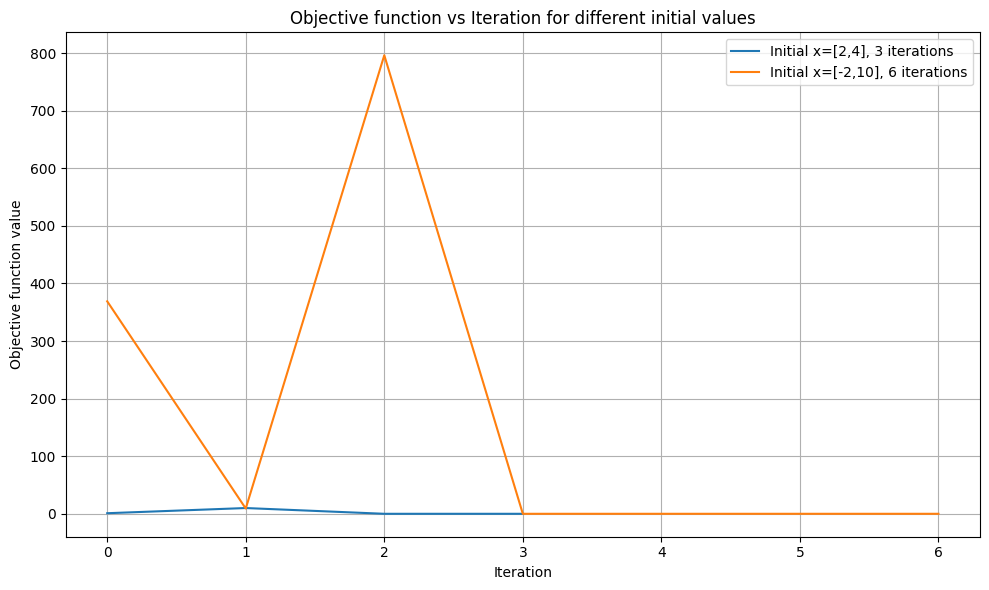

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(values_1, label=f'Initial x=[2,4], {iters1} iterations')
plt.plot(values_2, label=f'Initial x=[-2,10], {iters2} iterations')
plt.xlabel('Iteration')
plt.ylabel('Objective function value')
plt.title('Objective function vs Iteration for different initial values')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


In [99]:

x1, y1, values_1, ds_1, hessians_1, iters1 = newton_method(rosenbrock_function, rosenbrock_gradient, rosenbrock_hessian, np.array([2, 4]))
x2, y2, values_2, ds_2, hessians_2, iters2 = newton_method(rosenbrock_function, rosenbrock_gradient, rosenbrock_hessian, np.array([-2, 10]))

Function converged in 3 iterations
Function converged in 6 iterations


## Task 2

In [33]:
def quasi_newton_method(obj_func, grad, x0, step, iters=10_000):
    x = x0
    n = len(x0)
    H = np.eye(n)
    objective_values = [obj_func(x)]
    ds = []
    hessians = [H.copy()]

    for i in range(1, iters + 1):
        g = grad(x)
        d = -H @ g
        ds.append(d)
        x_new = x + step * d
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        z = y - H @ s
        denominator = z @ s
        if abs(denominator) > 1e-6:
            H = H + (z @ z.T )/ denominator
        x = x_new
        hessians.append(H.copy())
        objective_value = obj_func(x)
        objective_values.append(objective_value)
        if abs(objective_values[i-1] - objective_value) < 1e-6:
            print(f"Function converged in {i} iterations")
            return x, objective_value, objective_values, ds, hessians, i

    print(f"Function did not converge in {iters}s iterations")
    return x, objective_value, objective_values, ds, hessians, step

In [39]:
x1, y1, values_1, ds_1, hessians_1, iters1 = quasi_newton_method(rosenbrock_function, rosenbrock_gradient, np.array([2, 4]), 1e-6)

x2, y2, values_2, ds_2, hessians_2, iters2 = quasi_newton_method(rosenbrock_function, rosenbrock_gradient, np.array([-2, 10]), 1e-8)

Function converged in 2335 iterations
Function did not converge in 10000s iterations


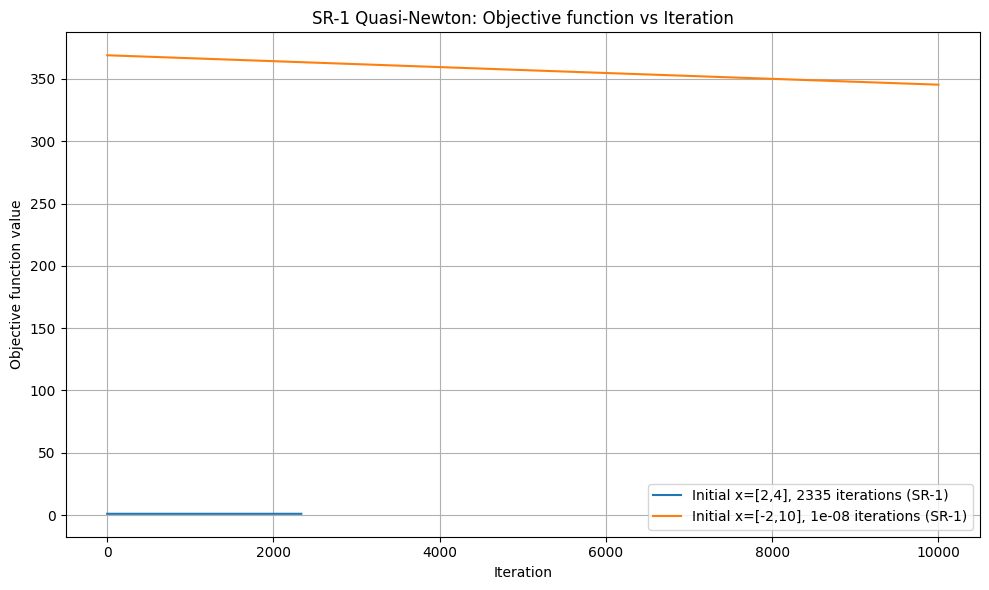

In [40]:

plt.figure(figsize=(10, 6))
plt.plot(values_1, label=f'Initial x=[2,4], {iters1} iterations (SR-1)')
plt.plot(values_2, label=f'Initial x=[-2,10], {iters2} iterations (SR-1)')
plt.xlabel('Iteration')
plt.ylabel('Objective function value')
plt.title('SR-1 Quasi-Newton: Objective function vs Iteration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:

x1

array([1.99669628, 3.99966019])

In [42]:
x2

array([-2.04714024,  9.98820225])

In [53]:
def quadratic_func(x):
    return x[0]**2 + x[1]**2

def gradient_func(x):
    return np.array([2*x[0], 2*x[1]])

def hessian(x):
    return np.array([
        [2, 0],
        [0, 2]
    ])

def quasi_newton_method(obj_func, grad, x0, step=1.0, iters=10_000):
    x = x0
    n = len(x0)
    H = np.eye(n)
    objective_values = [obj_func(x)]
    ds = []
    hessians = [H.copy()]

    for i in range(1, iters + 1):
        g = grad(x)
        d = -H @ g
        ds.append(d)
        x_new = x + step * d
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        z = y - H @ s
        denominator = z @ s
        if abs(denominator) > 1e-6:
            H = H + np.outer(z, z) / denominator
        x = x_new
        hessians.append(H.copy())
        objective_value = obj_func(x)
        objective_values.append(objective_value)
        if abs(objective_values[-2] - objective_value) < 1e-6:
            print(f"Function converged in {i} iterations")
            return x, objective_value, objective_values, ds, hessians, i

    print(f"Function did not converge in {iters} iterations")
    return x, objective_value, objective_values, ds, hessians, iters


In [58]:
new_x = [2, 1]
x3, y3, values_3, ds_3, hessians_3, iters3= quasi_newton_method(quadratic_func, gradient_func, new_x, 0.5)

Function converged in 2 iterations


In [59]:
x3

array([0., 0.])

In [50]:
y3

2.0